# 14. キャップストーン:1つの回帰、3つのレンズ(ニューラルネットの視点)

線形代数編と**まったく同じデータ**(`make_capstone_dataset`)・同じ多項式特徴を使う。

この章のレンズ:多項式回帰を **1層の微分可能なモデル** $\hat y = \Phi w$ とみなし、損失を勾配降下で下げる。すると線形代数が一発で出した**閉形式リッジ解に、反復で収束する**。weight decay(係数の $L_2$ 罰則)が、ちょうどリッジの $\lambda$ 項に対応する。

```{admonition} 核心 — ひとことで
:class: tip
**多項式回帰を「1 層の微分可能モデル $\hat y=\Phi w$」とみなして勾配降下すると、線形代数編の閉形式リッジ解に収束する。**
weight decay（係数の $L_2$ 罰則）＝リッジの $\lambda$ 項＝ベイズのガウス事前 — 同じ $\lambda$ が 3 つの言葉で呼ばれている。
線形代数は「到達点」を一発で、ニューラルネットは「そこへの道のり」を見せる。
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import plotly.io as pio

from nn_textbook import plotting as viz
from nn_textbook.datasets import make_capstone_dataset

pio.renderers.default = "plotly_mimetype+notebook_connected"

x, y = make_capstone_dataset(seed=0)
x_grid = np.linspace(x.min(), x.max(), 200)
f_true = np.sin(1.5 * x_grid) + 0.3 * x_grid
print(f'{len(x)} points')

40 points


## モデルと勾配

予測 $\hat y = \Phi w$、損失 $L(w) = \tfrac12\lVert \Phi w - y\rVert^2 + \tfrac{\lambda}{2}\lVert w\rVert^2$。

勾配は $\nabla L = \Phi^\top(\Phi w - y) + \lambda w$。これを下る = 勾配降下 + weight decay。

In [2]:
def poly_features(x, degree, stats=None):
    """Polynomial design matrix; standardize non-constant columns (stable fits).

    Returns (Phi, stats); pass stats back to transform a fresh grid the same way.
    """
    X = np.vander(np.asarray(x, dtype=float), degree + 1, increasing=True)
    if stats is None:
        mu, sd = X[:, 1:].mean(0), X[:, 1:].std(0)
    else:
        mu, sd = stats
    Xs = X.copy()
    Xs[:, 1:] = (X[:, 1:] - mu) / sd
    return Xs, (mu, sd)

def gradient_descent(Phi, y, lam, n_iter=4000):
    """GD on the ridge objective; returns (weights, data-MSE history)."""
    gram = Phi.T @ Phi + lam * np.eye(Phi.shape[1])
    lr = 1.0 / float(np.linalg.eigvalsh(gram).max())  # 1 / Lipschitz constant
    w = np.zeros(Phi.shape[1])
    hist = []
    for _ in range(n_iter):
        w = w - lr * (Phi.T @ (Phi @ w - y) + lam * w)
        hist.append(float(np.mean((Phi @ w - y) ** 2)))
    return w, hist

degree = 12
Phi, stats = poly_features(x, degree)

## 学習曲線:正則化が収束を安定させる

いくつかの $\lambda$ で勾配降下を回し、データ MSE の下がり方を比べる。スライダーを動かすとエポック窓が広がる(各設定がどれだけ速く下げ止まるか)。

In [3]:
lams = [0.0, 0.1, 1.0, 10.0]
histories, labels = [], []
for lam in lams:
    _w, hist = gradient_descent(Phi, y, lam, n_iter=600)
    histories.append({'loss': hist})
    labels.append(f'lambda={lam:g}')
fig = viz.plotly_training_curves(histories, labels, title='Gradient descent: data MSE by lambda')
fig.show()

## 勾配降下は閉形式リッジ解に収束する

十分に回した勾配降下の重みを、線形代数編の閉形式 $w^\star = (\Phi^\top\Phi + \lambda I)^{-1}\Phi^\top y$ と比べる。一致する。

max |w_gd - w_closed| = 2.33e-14


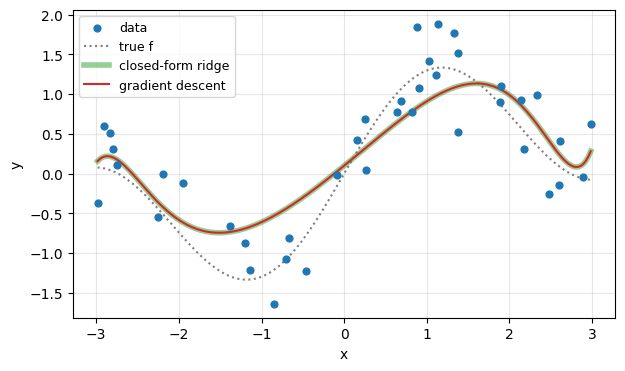

In [4]:
lam = 1.0
w_gd, _ = gradient_descent(Phi, y, lam, n_iter=20000)
w_closed = np.linalg.solve(Phi.T @ Phi + lam * np.eye(Phi.shape[1]), Phi.T @ y)
print(f'max |w_gd - w_closed| = {np.max(np.abs(w_gd - w_closed)):.2e}')

Phi_g, _ = poly_features(x_grid, degree, stats)
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x, y, s=24, color='#1f77b4', zorder=3, label='data')
ax.plot(x_grid, f_true, color='gray', lw=1.5, ls=':', label='true f')
ax.plot(x_grid, Phi_g @ w_closed, color='#2ca02c', lw=4, alpha=0.5, label='closed-form ridge')
ax.plot(x_grid, Phi_g @ w_gd, color='#d62728', lw=1.5, label='gradient descent')
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xlabel('x'); ax.set_ylabel('y');

## 橋渡し

線形代数は**到達点**(閉形式解)を一発で与え、ニューラルネットは**そこへの道のり**(勾配降下)を見せる。残るは、その解の**周りの不確実性**——それがベイズ編の役割。

weight decay = リッジ罰則 = ガウス事前。同じ $\lambda$ が3つの言葉で呼ばれている。

## 3つのレンズへのリンク

同じデータ・同じ答えを、3冊が別の角度から照らす。

- **線形代数** — `analytics/linear_algebra` 12章「キャップストーン」:正規方程式の閉形式解・SVD・リッジ
- **ニューラルネット** — `analytics/neural_net` 14章「キャップストーン」:勾配降下が同じ解に辿り着く
- **ベイズ** — `analytics/bayesian` 13章「キャップストーン」:重みの事後分布と予測の不確実性

3視点を並べたショーケールは統合ポータル(`analytics/report`、`make report`)の「統合」ページにもある。